# Lab 059 · When validation becomes training

[Lesson](../lessons/0059-validation-set-overfitting.html) · [Reference](../reference/0059-validation-set-overfitting.html) · [Evidence](_verify_l059_v2_results.json) · [Reproduction](l059-reproduction.md)

**Skill:** distinguish selecting a model from evaluating the complete selection procedure. Five live code TODOs, independent CHECKs and a written EXIT. The paper's KRR equations and synthetic generator are visible below; the experiments are a declared protocol extension, not a reproduced paper figure. CPU only, no external data/checkpoint downloads in the core experiment. The 1,000-repeat precision track can take several minutes. Retrieval → input → implementation → measured evidence → teach-back. Author-reference figures are not outputs of this kernel.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## The validation set becomes training data for your decisions

**Outcome:** implement and audit the boundary between choosing a procedure and estimating its performance. You will trace a winner selected from noise, reconstruct the paper's kernel ridge and leave-one-out equations, and run a nested evaluation that survives a held-out-label mutation test. This is an evaluation lesson; the kernel model is a fully visible measuring instrument.

A **parameter** is fitted inside a model, such as a regression coefficient. A **hyperparameter** controls that fit, such as regularization strength. A **selection criterion** is a score used to choose hyperparameters, features, checkpoints, or ensemble weights. A **performance estimate** answers how well the resulting procedure predicts new observations. The same number cannot automatically serve both purposes after you minimize it.

Suppose your relational predictor gains .01 in validation AUC after your eighth feature-history redesign. That may be useful development. It does not yet establish that relational structure beats a strong flat-table baseline: the procedure includes all eight designs and the decision to retain this one. In lesson 057, out-of-fold (OOF) means each row was excluded from fitting its own base predictor. The row's target can nevertheless fit the ensemble selector. In lesson 058, selecting tasks to preserve known-model rankings can specialize the benchmark itself. Here the adaptive object is the model-selection procedure.

**Retrieve first:** explain why an OOF combiner needs its own evaluation boundary. Then name one decision that consults validation labels without computing a gradient. Keep your answer until the EXIT teach-back.

The primary reading is [Cawley and Talbot (2010), full paper](https://jmlr.org/papers/volume11/cawley10a/cawley10a.pdf). Read §§2–3 for the instrument and data, §4 for selection overfitting, and §5 for biased evaluation protocols. These are separate empirical arguments. The paper does not introduce a new neural architecture or claim every larger search must worsen test performance.

## A minimum selects lucky noise

Fix the training sample and candidate predictors. Candidate j has unknown expected new-data error μ_j. Its observed validation estimate is μ_j + ε_j, where ε_j is sampling noise. If the estimates are unbiased for each fixed candidate, the expectation of each ε_j is zero. The selected index j* minimizes the **observed** estimates, so ε_j* is no longer an unselected draw. This conditioning is the source of optimism.

For three equally good candidates with true error .30, suppose observed errors are .33, .26, .31. The second wins, but its underlying error remains .30 in this example. With unequal true errors, selection mixes useful discovery and lucky noise: finding a better candidate and overestimating its improvement can happen together. Perfectly duplicated candidates create no additional opportunities; correlated candidates lie between duplication and independent draws. Raw search count alone does not determine the bias.

A small exact example makes the expectation visible. Each of two equally good candidates independently reports .4 or .6, each with probability one half, around true error .5. The four equally likely pairs have minima .4, .4, .4, .6. Their mean is .45. The expected fresh-test error remains .5. **Optimism** here is fresh-test loss minus the selected estimate; positive values mean the selection score looked too favorable.

### State the random object before drawing a conclusion

For fixed candidate j, an expectation over newly sampled validation sets can be centered on its true risk. After choosing j*, we instead average the performance of whichever candidate each sample selects. An argmin and an expectation do not generally commute: the expected minimum of noisy estimates is not the minimum of their expectations. This is already visible in the .4/.6 enumeration.

Candidate duplication is an informative edge case. Copying an existing column 100 times cannot alter its observed minimum; independently generating 100 columns can. This separates the number of stored predictions from the number of different selection opportunities. Correlated fitted models require their actual joint error distribution, not the independent-binomial formula.

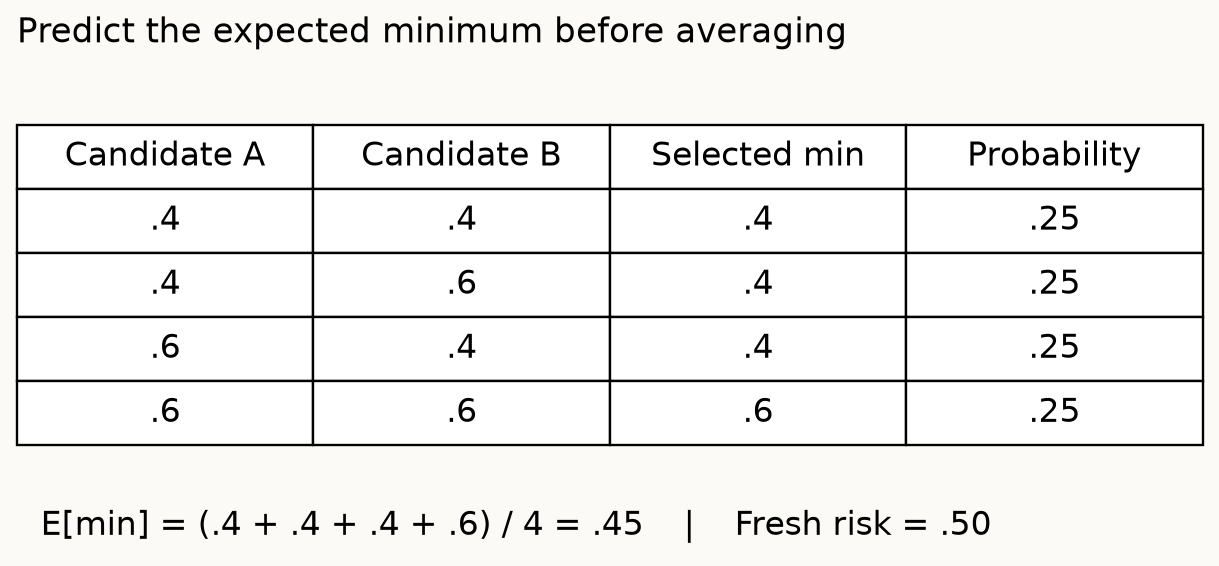

Synthetic two-candidate enumeration. Average selected minima, not candidate expectations. [Open full-size figure](figures/l059/null-minimum.png).

A constant upward bias need not change which candidate wins. Adding .1 to every estimate preserves the argmin. Independent fluctuations can reverse the ordering even when their mean is zero. This is the distinction in the paper's §4.1/Figure 3: good selection needs a reliable minimum, whereas good evaluation needs a reliable reported level. It does not imply biased evaluation is acceptable.

## Run a negative control you can explain completely

A **negative control** removes predictive signal while preserving the operation being tested. The historical lab generates independent Bernoulli(.5) labels and predictions, selects the lowest classification error on 80 validation rows, and evaluates the frozen candidate on 2,000 independent test rows. Labels are balanced **in expectation**, not forced to exactly half of each class. All candidate predictors have expected error .5.

There are 200 repetitions and candidate budgets 1, 4, 16, 64, 256. Within a repetition, candidates are nested prefixes and each candidate has its own reproducible test prediction vector. Budget comparisons are therefore paired. The saved `seed` field is the repetition index; the actual RNG seed is 59 plus that index. Separate validation/test streams prevent changing the budget from accidentally moving the test stream. Generating every candidate's test predictions after selection is fine if only the frozen index is evaluated; searching those test predictions would be a different, invalid protocol.

**Predict:** must the selected validation minimum fall as the candidate budget grows? Must the selected test error be monotone? Which claim is a deterministic property of nested sets and which is an expectation over random data?

The preserved 200-repeat evidence gives validation error .495875 at one candidate and .342188 at 256; fresh-test error at 256 is .497868. Optimism is .155680, with Monte Carlo SE .001652. A **Monte Carlo standard error** is the sample SD of per-repeat gaps divided by √200; it measures precision of this simulation average, not uncertainty across real datasets. The 256-minus-1 comparison must subtract within each repetition before computing its uncertainty.

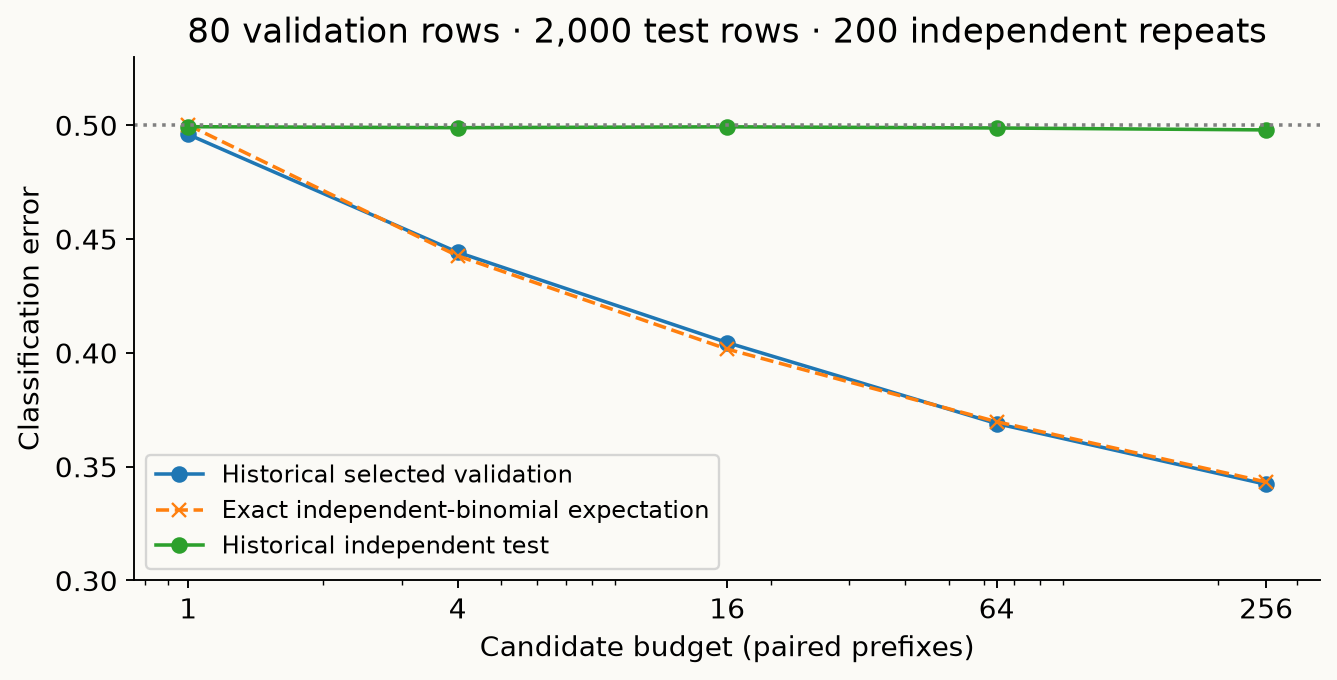

Preserved historical 200-repeat null control and the exact independent-binomial expectation. No new training or paper result reproduction. [Open full-size figure](figures/l059/null-results-v2.png).

The historical operator and JSON remain unchanged. The new lab replays all 1,000 saved repeat-budget rows with your live selector, then reanalyzes them with your paired-summary function. This validates historical arithmetic without pretending these are newly trained models. It also computes an independent exact expectation: if B_j is Binomial(n,.5), then

`E[min_j B_j/n] = (1/n) Σ[k=0..n−1] P(B > k)^M`.

Here n is the validation row count and M the number of independent candidates. A nonnegative integer variable equals the number of thresholds it exceeds; taking expectations gives the survival sum. Independence across candidates turns the probability that **every** candidate exceeds a threshold into a power. At M=1 the result is .5. At n=1, M=2 it is .25. This formula is exact for this independent control, not a correction formula for correlated real models.

## What the paper actually measures

The noise control teaches optimistic selection, but it does not reproduce the paper's signal-bearing experiments. In §3.1 the authors specify four equally likely Gaussian components in two dimensions. Two positive components have centers (.4,.7) and (−.3,.7); negative components have centers (−.7,.3) and (.3,.3). Each coordinate has variance .04, hence standard deviation .2. There is real signal and unavoidable overlap. The paper reports a Bayes classification error of about 12.38%; this is a published optimum for classification, not a target value for mean squared error.

Figure 2 uses 1,000 independent 64-row datasets, an automatic relevance determination (ARD) kernel, four-fold cross-validation MSE, and iterative hyperparameter optimization. Its expected test curve initially improves and later rises. Figures 4–8 instead hold 256 fitting rows fixed, vary independent validation samples of 64 or 256 rows, and inspect a smoothed classification error surface. More validation data makes the selected hyperparameters less variable in that experiment. These are different experiments; neither is a random-label test.

The practical evidence comes from thirteen benchmark datasets (§3.2/Table 1), with 100 released train/test realizations per dataset except image and splice with 20. In Table 2, a more flexible ARD kernel can obtain a better selected PRESS criterion yet worse test classification error than an isotropic RBF kernel. More representational capacity can coexist with a less reliable tuning procedure. This finding does not establish that ARD is intrinsically inferior or that every ensemble should use fewer members.

In §5.2, the problematic “median” protocol tunes the first five training realizations, takes componentwise medians of their hyperparameters, then reuses those settings across all realizations. Test rows in one split can have influenced selection in another. Moreover, averaging reduces selection variability, so the evaluated procedure differs from tuning anew in each split. In §5.3, “external” selection uses the whole dataset before outer cross-validation; each outer test row can influence its hyperparameters. The remedy is to rerun selection internally within each outer training portion. The revised lab executes this latter distinction.

## Reconstruct the measuring instrument: model architecture

Kernel ridge regression predicts a real number f(x), then classifies by f(x)≥0 for +1. A **kernel** measures similarity to training rows without explicitly constructing nonlinear features. The Gaussian radial basis function (RBF) kernel is exp(−η‖x−z‖²). Increasing positive η makes similarity decay faster with distance. ARD uses one η_q per input coordinate: exp(−Σ_q η_q(x_q−z_q)²). Equal coordinate scales recover RBF.

For x=(.4,.7), z=(−.3,.7), and η=(2,.25), the weighted squared distance is 2×.7²+.25×0²=.98, so similarity is exp(−.98)≈.3753. Changing the second scale cannot affect this pair because its second coordinates agree. That is a computation you should be able to predict before running the kernel.

Let X contain n rows and d=2 features, K be its n×n kernel matrix, y the length-n ±1 targets, α the length-n coefficients, and b an unpenalized intercept. The paper's objective is one half of squared feature-space weight norm plus `Σ(y−f)²/(2λ)`, with positive regularizer λ. Stationarity gives α=(y−f)/λ and Σα=0. Substituting f=Kα+b produces the augmented linear system (paper Eq.3):

`C = [[K + λI, 1], [1ᵀ, 0]];  C [α; b] = [y; 0]`.

I is the identity matrix and 1 is an all-ones column. The final equation constrains Σα=0; the final unknown supplies b. Dropping that row/column silently changes the estimator. The visible code solves this system in float64. For new X*, predictions are K(X*,X)α+b. No labels of X* enter fitting or selection. These real-valued scores are not probabilities: the classification head returns +1 for f≥0 and −1 otherwise, while the selection criterion uses squared score residuals. The signed, unnormalized coefficients differ from TabR’s nonnegative softmax neighbor weights; a distant query approaches b as its similarities decay. The tiny implementation forms the full inverse to expose its diagonal; its cubic solve cost and quadratic storage are unsuitable for a large benchmark without a more efficient solver.

### Why the inverse diagonal gives a deleted residual

Reorder the augmented system so row i comes first, and write C as blocks [a, vᵀ; v, B]. B contains all other training rows plus the intercept equation. Deleting i solves B z = [y_other; 0], so its held-out prediction is vᵀ B⁻¹[y_other; 0]. Its residual is therefore r = y_i − vᵀ B⁻¹[y_other; 0]. Eliminating the remaining coefficients from the full system gives α_i = r / (a − vᵀB⁻¹v).

The same block inverse identity gives (C⁻¹)_ii = 1 / (a − vᵀB⁻¹v). Dividing α_i by this diagonal entry recovers r. That is why the shortcut equals explicit refitting **at fixed hyperparameters**. It does not mean the minimum over hyperparameters is an unbiased performance estimate; selecting the hyperparameters was a second operation.

The identity assumes the deleted fit exists. Positive λ and the valid RBF/ARD kernel make the intended small fits well-defined. The lab rejects nonpositive inverse diagonals and invalid scales. It exposes numerical equations rather than replacing them with a library estimator whose intercept convention may differ.

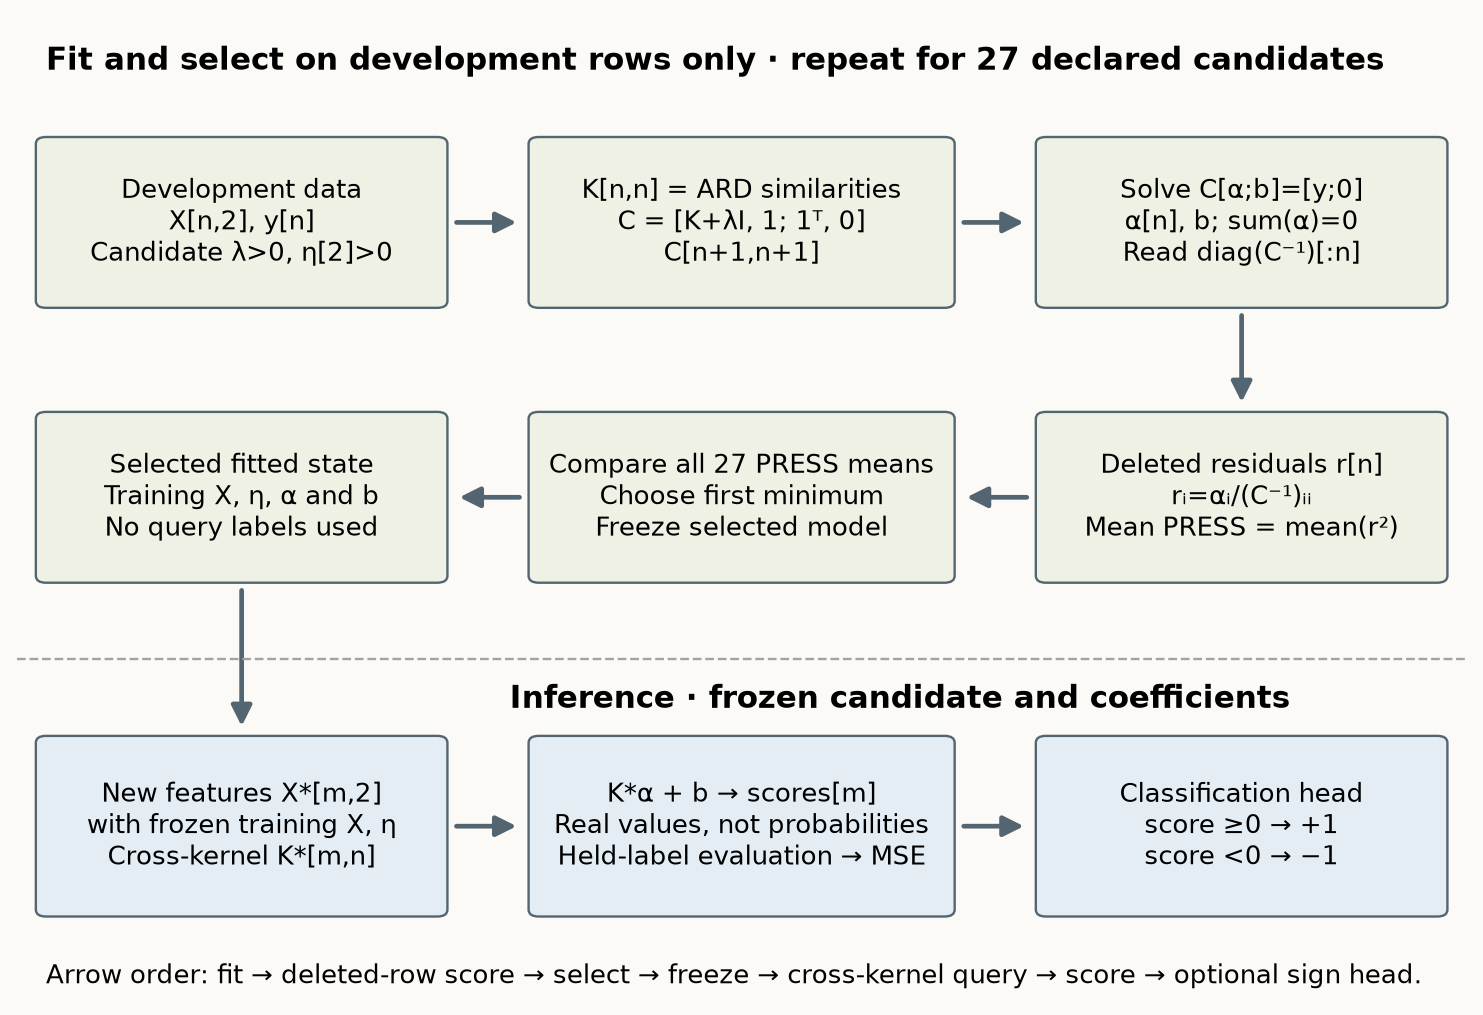

End-to-end KRR: candidate fitting and PRESS selection above; frozen-model cross-kernel inference and sign head below. Queries supply features only. [Open full-size figure](figures/l059/architecture-v2.png).

The connected diagram separates fitting/selection from inference. For each candidate, the solve already fits all available development rows; LOO scores that fixed recipe through deleted residuals. The minimum chooses which fitted model is frozen. At inference only new features enter; scores feed the squared-error evaluation and the sign head supplies classification. The following operation table expands one numerical kernel calculation.

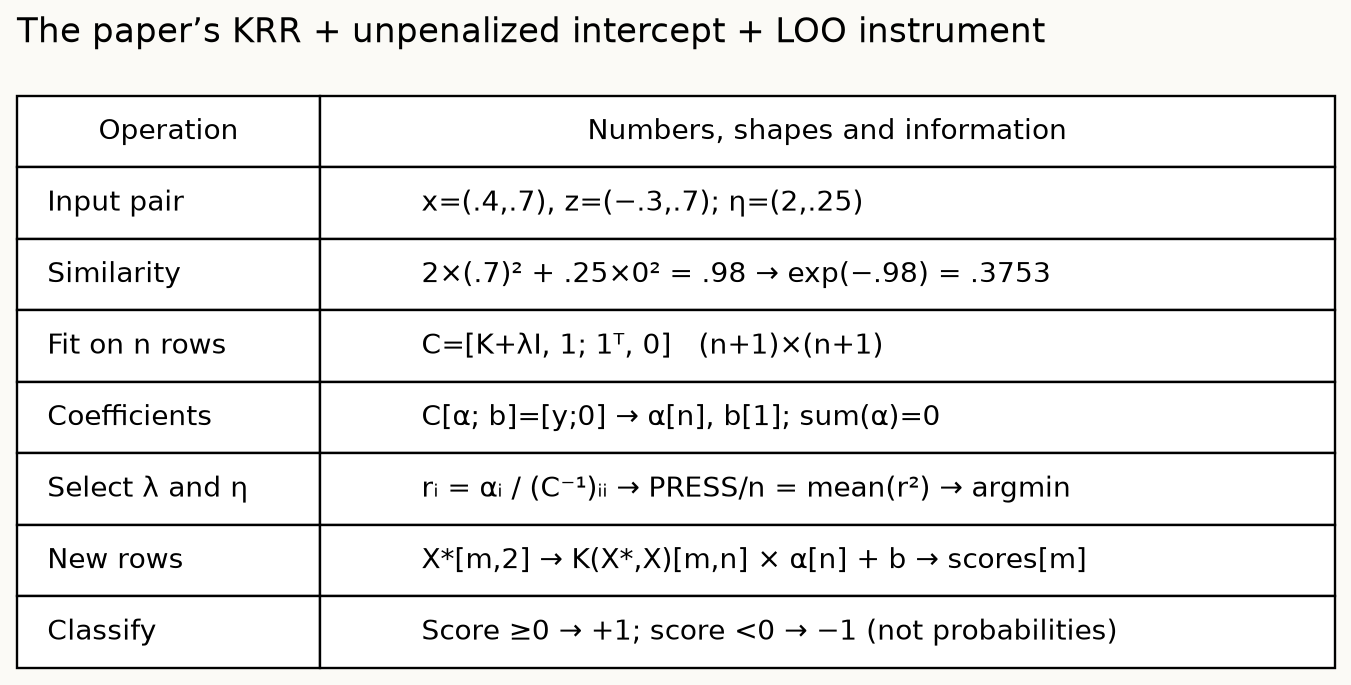

Paper equation instrument: ARD similarity, augmented KRR/intercept solve, deleted residuals and new-row predictions. [Open full-size figure](figures/l059/kernel-v2.png).

Leave-one-out (LOO) removes row i, fits the same fixed hyperparameters on all other rows, and predicts row i. The paper's §2.1 identity gives its deleted residual as `r_i^(−i) = α_i / (C⁻¹)_ii`, using the **upper-left n diagonal entries of the augmented inverse**. PRESS is the sum of these squared deleted residuals; the lab divides by n to report MSE. Dividing by the fixed row count leaves candidate ordering unchanged. Ordinary fitted residuals use a model that has seen y_i and are not the same quantity.

The lab independently verifies this identity against actually leaving out each row and refitting. It also tests the intercept with constant training targets and a distant query. The provided model source is readable in the notebook; your live tasks implement selection, deleted residuals, candidate search, outer nesting, and paired inference.

## Nest the decision that is actually adaptive

An **outer fold** is an evaluation partition. For each outer fold, the remaining rows are the development sample. LOO selection is performed again on that development sample; the selected model is fitted on those rows and predicts only the outer-held rows. Each row receives exactly one OOF prediction. The final reported outer MSE averages squared errors across all rows. This estimates the whole selection-and-fit procedure at the outer training size.

In the worked protocol, a 64-row dataset is split into four equal label-blind shuffled blocks. Each internal selection sees 48 rows; each of its LOO fits effectively trains on 47. After selection, a 48-row refit predicts the held 16. In the deliberately contaminated external comparator, LOO selection first sees all 64 targets and freezes one candidate for all four outer refits. Those 48-row models still excluded their evaluation rows from coefficient fitting, but their **choice** already depended on those rows.

### Name the procedure whose risk is being estimated

Let A map a training sample to a fitted predictor, including every preprocessing and selection step. An outer held-out score estimates prediction from A applied to an outer training sample. The final deployed fit applies A to a larger sample. Their expected risks can differ; nested cross-validation does not promise an unbiased estimate for a particular final fitted model.

For the external comparator, define its frozen candidate using all 64 labels, then refit coefficients on 48. Fresh rows can honestly evaluate this unusual procedure. The problem is reporting its scores on the 16 rows whose labels already helped select that candidate. Comparing its held-out and fresh scores at the same 48-row coefficient fit isolates this contamination more cleanly than subtracting a64-row final-fit score.

A high nested score can be an accurate warning that the whole search procedure is unreliable. Improve that procedure using development evidence, then evaluate the revised version independently. Choosing which nested score to report after inspecting ten grids would add a new outer layer of adaptation.

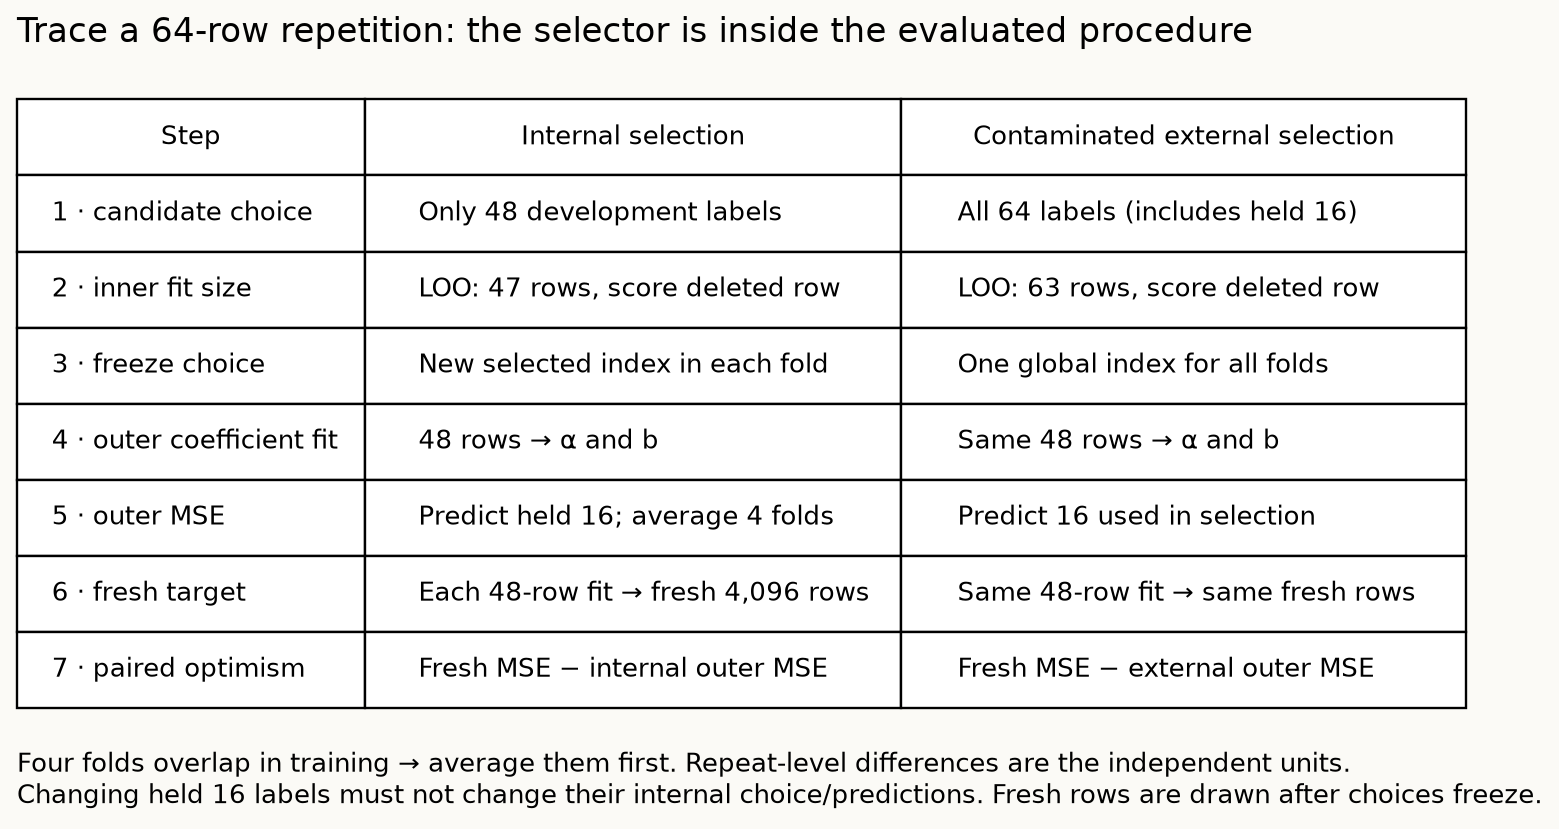

Declared 64-row nested/external protocol. Same 48-row outer models supply each matched fresh target. Four folds are averaged within a repetition. [Open full-size figure](figures/l059/protocol-v2.png).

**Trace before running:** change the targets in outer fold 2. Its own internal selected hyperparameters and predictions must remain unchanged. Other folds may change because those rows legitimately belong to their training portion. The CHECK enforces this distinction. Mere disjointness of model fitting rows is insufficient to protect a globally selected hyperparameter.

A model refitted on 64 rows and a model refitted on 48 rows have different evaluation targets. The experiment therefore creates fresh independent rows only after freezing every choice and evaluates **each outer-fitted model** on those fresh rows. It averages their fresh MSE within the repetition. Subtracting each protocol's outer score from its own matched fresh score measures optimism without attributing a training-size effect to leakage. The 64-row refit's fresh score separately evaluates selected LOO optimism; its LOO fits used 63 rows, so that comparison retains a small training-size difference.

Nested evaluation does not repair a poor selector. Its job is to include that selector's mistakes in the estimate. Nor does it protect a researcher who redesigns the candidate grid after viewing outer scores. That redesign needs new evidence. For customer histories or temporal data, replace random folds with deployment-appropriate entity/time boundaries and label-availability rules; random nesting cannot remove temporal leakage.

## Measure the boundary, with uncertainty

The new protocol is fixed before the author run: 27 candidates from λ∈{.01,.1,1} and each of two η coordinates in {.25,2,16}; analytic LOO mean PRESS; first-index ties; four equal outer folds; 64 development rows; 4,096 fresh rows per independent repetition; no learned preprocessing or feature selection. There are 30 teaching repetitions, seeds 5900–5929, followed by a required 1,000-repetition precision track, seeds 5900–6899. The longer run contains the first 30; they are not independent confirmations.

The same candidates, development rows, outer folds and fresh rows are paired across internal/external protocols. All four folds are averaged **inside** each repetition. The independent units are fresh draws of the entire synthetic dataset, not the four overlapping folds or the 4,096 test rows treated as separate experiments. Intervals are paired Student-t intervals for the mean repeat-level difference; they quantify Monte Carlo precision under this generator. They are not benchmark-dataset confidence intervals and are exploratory across multiple contrasts.

**Predict:** will the external outer score look better? Can its actual fresh score also be better because its selection legitimately used more information, even though its claimed evaluation was contaminated? Should the internal estimated optimism be exactly zero in a finite run?

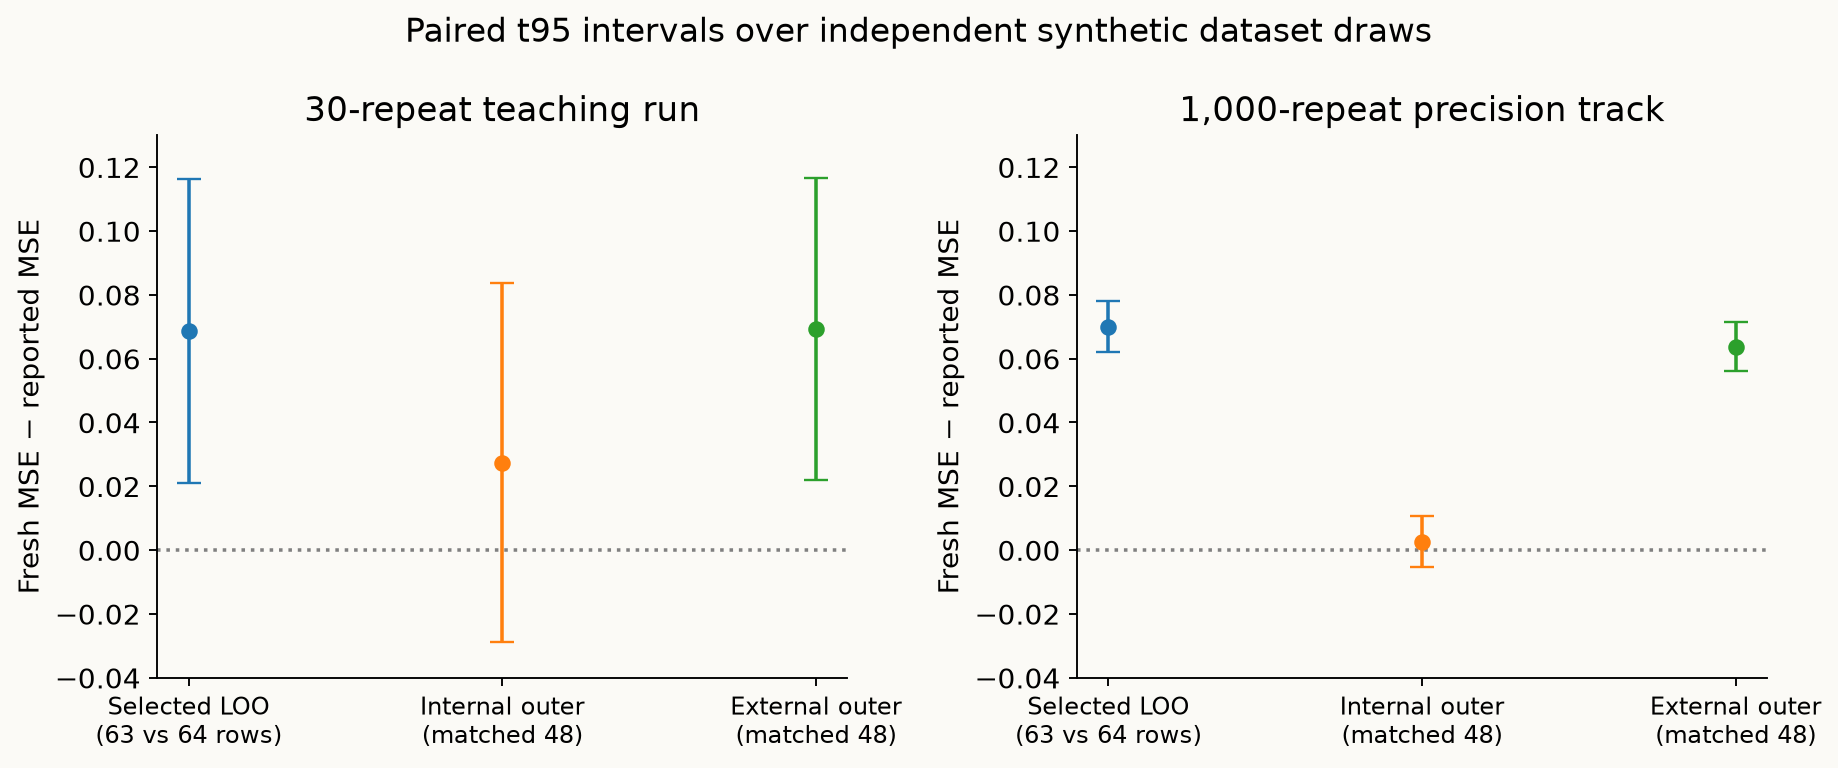

Fresh author runs:30 and 1,000 independent synthetic repeats, with paired t95 intervals. The 1,000 contain the first 30. Selected LOO has a63/64 training-size difference; outer contrasts match 48 rows. [Open full-size figure](figures/l059/nested-results-v2.png).

On the 30-repeat teaching run, internal outer MSE is .482096 versus matched fresh MSE .509442; the optimism estimate is .027346 with 95% interval [−.028857,.083549]. External outer MSE is .416708 versus its matched fresh MSE .485978; optimism is .069269 [.022023,.116516]. The internal-minus-external outer-score gap is .065387 [.045771,.085004]. These gaps are distinct quantities. The wider internal interval includes zero; that neither proves exactly zero bias nor establishes equivalence. The external fresh score being lower does not make its external outer score a valid estimate.

The [1,000-repeat evidence](_verify_l059_closer_results.json) gives internal matched optimism .002660 with t95 [−.005395,.010715], and external matched optimism .063726 [.055963,.071489]. External fresh MSE is .492255 versus internal .510056: the external selector saw 64 labels rather than 48, so this is not an equal-information-budget model contest. The bias comparison evaluates each frozen procedure against its own matched fresh target. The figure shows the precision extension. Read its complete contrast summary rather than selecting whichever seed, contrast or interval best supports the story. A run that fails to show the anticipated pattern would remain valid evidence under the prespecified protocol; the lab's correctness checks do not require a particular statistical victory.

## Audit an ensemble without blaming diversity

A uniform mixture of a fixed declared member set has no fitted weights, but the decision to choose that member set can still be adaptive. Greedy ensemble selection fits weights to OOF predictions. Selecting its maximum steps, base library, loss, folds or preferred prefix adds decisions. Protect the entire path, then compare it with a single-family procedure selected by the **same inner evidence**. The family with best final test loss is an oracle comparator, not a deployable choice.

A large OOF-to-test gap can also reflect temporal shift, dependence among customers, a 48-versus-64-row refit difference, or ordinary sampling uncertainty. The current synthetic generator removes temporal shift and controls sample size; it cannot diagnose every real failure. A useful discriminating experiment freezes all recipes and changes only the amount of selection data, or evaluates the complete procedure on new outer blocks.

The bigger lesson connects strong defaults (053), ensembles (057), benchmark construction (058), and the upcoming model comparison (060). Strong defaults reduce local decisions but inherit the assumptions of their original development. Ensembling may reduce prediction variance while increasing selection flexibility. Benchmark reuse can adapt research decisions over years. A fair relational claim compares complete pipelines on aligned future entities/times, gives each a declared tuning budget, and reserves evidence for the final decision. Architectural novelty does not excuse a weaker evaluation boundary.

## Exit: make adaptation countable

Finish all five live functions, replay the historical control, run the 30-repeat kernel protocol and required 1,000-repeat precision track, then submit `data/cache/l059-student/exit.json` and your completed notebook. The artifact records numerical results, live function sources, source evidence hashes, and an adaptation ledger. No learner mastery is inferred from building or executing the teacher notebook.

Write 80–180 words identifying: the selected object; why coefficient-level OOF exclusion is insufficient; the training size behind each estimate; one measured interval and its unit; and one next experiment that could contradict your interpretation. Freeze a lesson-060 candidate list, metric, split identity, selection rule and budget. Name one tempting adjustment you will postpone until a separately labeled follow-up. Ask the tutor to check this argument, especially any numerical result that seems to contradict the expected mechanism.

## Reproduction boundary and reading route

**Equation validation:** the augmented KRR system and exact LOO identity pass independent refit tests. **Historical evidence:** all 1,000 null rows replay under the preserved operator. **New procedure:** internal/external selection and matched fresh evaluation run with your live notebook functions. **Original results:** INCOMPARABLE, not reproduced.

The new run uses the paper's exact synthetic distribution and kernel/LOO equations, but substitutes a finite 27-candidate ARD grid and outer four-fold protocol. It does not reproduce Figure 2's iterative optimizer/four-fold inner criterion, Figures 4–8's SER surface and fixed fitting sample, or Table 8's thirteen real benchmarks and outer ten-fold RBF experiment. Matching 1,000 repetitions is a precision choice, not protocol parity. The original HTTP GKM link in footnote 2 works, although its HTTPS endpoint fails certificate verification. We pinned the downloaded archive and inspected its KRR, RBF, LOO, criterion, cross-validation and simplex source. Its KRR implementation uses a Cholesky solve with the same intercept and a Schur-corrected inverse diagonal. A translated source-algebra check agrees on 18 fixtures; native MATLAB execution, optimizer trajectories and exact 2010 experiment-version parity are not established. Its SSE adapter reports half the residual sum of squares, while our fixed-n mean PRESS has the same argmin. See the [source comparison](_source_check_l059_v2_results.json) and [pinned reference files](sources/l059/README.md). There is no appendix in this 29-page article; the full substantive §§2–6 and figure/table captions were inspected.

Use the [reference card](../reference/0059-validation-set-overfitting.html), [equation/behavior checks](_check_l059_v2_results.json), [source inventory](_sources_l059_v2.json), [measured evidence](_verify_l059_v2_results.json), and [reproduction commands](l059-reproduction.md) together. The latter documents the operator and what remains unrun. Read §4.1 for criterion variance, §4.4 for regularization/averaging strategies, and §§5.1–5.3 for the full evaluation boundary; none makes repeated final-test use free.

## Start the live implementation
Your functions drive both the preserved null replay and the fresh nested experiment. The provided kernel instrument is a direct implementation of the equations, not an imported substitute for the exercises. No preprocessing is refitted inside LOO; doing so would change the deletion identity. Read the source from input to prediction before solving the five small operations.

In [ ]:
# PROVIDED — setup and versions
import sys,json,hashlib,inspect,functools,importlib.metadata
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.linalg import solve
from scipy.stats import t,binom
from threadpoolctl import threadpool_limits
from IPython.display import display
for p in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (p/'relkit').is_dir():ROOT=p.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run the Colab bootstrap or start in the course repository')
print({name:importlib.metadata.version(name) for name in ['numpy','scipy']})

### PROVIDED · Paper§3.1 exact Gaussian mixture

In [ ]:
# PROVIDED — Paper§3.1 exact Gaussian mixture
def mixture(n, seed):
    """Paper §3.1: equiprobable components, variance .04 on each coordinate."""
    rng = np.random.default_rng(seed)
    centers = np.array([[.4,.7],[-.3,.7],[-.7,.3],[.3,.3]])
    component = rng.integers(0, 4, n)
    return centers[component] + rng.normal(0, .2, (n, 2)), np.where(component < 2, 1., -1.)

### PROVIDED · Paper§4 ARD kernel

In [ ]:
# PROVIDED — Paper§4 ARD kernel
def kernel(x, z, eta):
    """Paper §4 ARD kernel; scalar eta recovers isotropic RBF."""
    return np.exp(-np.sum((x[:,None,:]-z[None,:,:])**2*np.asarray(eta), axis=2))

### PROVIDED · PaperEq 3 augmented system, including b

In [ ]:
# PROVIDED — PaperEq3 augmented system, including b
def krr_fit(x, y, regularization, eta):
    """Paper Eq (3): unpenalized intercept b, constraint sum(alpha)=0."""
    x, y = np.asarray(x,float), np.asarray(y,float)
    eta = np.asarray(eta,float)
    if x.ndim != 2 or len(x)<2 or y.shape!=(len(x),) or not np.isfinite(x).all() or not np.isfinite(y).all():
        raise ValueError('Finite X[n,d], y[n] with n>=2 required')
    if not np.isfinite(regularization) or regularization<=0 or not np.isfinite(eta).all() or (eta<=0).any() or eta.shape not in [(),(x.shape[1],)]:
        raise ValueError('Positive lambda and scalar or d-coordinate eta required')
    n=len(x); c=np.empty((n+1,n+1))
    c[:n,:n]=kernel(x,x,eta)+regularization*np.eye(n)
    c[:n,n]=1.; c[n,:n]=1.; c[n,n]=0.
    inverse=solve(c,np.eye(n+1),assume_a='sym')
    coefficients=inverse @ np.r_[y,0.]
    return dict(x=x,alpha=coefficients[:n],bias=float(coefficients[n]),
                inverse_diagonal=np.diag(inverse)[:n],eta=eta)

### PROVIDED · New-row prediction without query labels

In [ ]:
# PROVIDED — New-row prediction without query labels
def predict_krr(model, x):
    return kernel(np.asarray(x),model['x'],model['eta'])@model['alpha']+model['bias']

### PROVIDED · Frozen 27-candidate finite grid

In [ ]:
# PROVIDED — Frozen27-candidate finite grid
def candidate_grid():
    # Fixed before outcomes: 3 regularizers × 3 scales per coordinate = 27.
    return [dict(regularization=l,eta=[e1,e2])
            for l in [.01,.1,1.] for e1 in [.25,2.,16.] for e2 in [.25,2.,16.]]

## TODO 1 · Freeze a choice using selection scores only

**Goal:** Return the first index of the minimum finite loss. Reject empty, nonfinite and non-vector inputs.

**Why:** Deterministic ties make a replay meaningful; the API must not receive test targets.

**Hint boundary:** Check shape and finiteness before choosing an index.

In [ ]:
# TODO — choose_validation
def choose_validation(errors):
    raise NotImplementedError("Implement this live protocol operation")

In [ ]:
# CHECK — deterministic ties and malformed score vectors
assert choose_validation([.3,.1,.1])==1, 'Keep the first equal minimum'
for bad in [[],[float('nan')],[.2,float('inf')],[[.1,.2]]]:
    try:choose_validation(bad)
    except ValueError:pass
    else:raise AssertionError('Reject empty, nonfinite or non-vector scores')

## TODO 2 · Recover actual deleted-row residuals

**Goal:** Return the paper §2.1 residual vector using the augmented inverse diagonal. Validate finite aligned nonempty vectors and strictly positive diagonal entries.

**Why:** Training residuals score a model that saw the target. Deleted residuals test the fixed recipe without that row.

**Hint boundary:** The Schur-complement derivation tells you which two quantities to combine; do not invert the diagonal again.

In [ ]:
# TODO — loo_residuals
def loo_residuals(alpha, inverse_diagonal):
    raise NotImplementedError("Implement this live protocol operation")

In [ ]:
# CHECK — compute deleted predictions by actual refitting (independent oracle)
x0=np.array([[0.,0.],[.2,.6],[.9,.3],[1.,.8],[.4,.2]])
y0=np.array([-1.,1.,-1.,1.,1.]); config0=dict(regularization=.3,eta=[2.,.5])
m0=krr_fit(x0,y0,**config0)
brute=[]
for i in range(len(y0)):
    keep=np.arange(len(y0))!=i
    brute.append(y0[i]-predict_krr(krr_fit(x0[keep],y0[keep],**config0),x0[i:i+1])[0])
np.testing.assert_allclose(loo_residuals(m0['alpha'],m0['inverse_diagonal']),brute,atol=1e-10,
  err_msg='Use the diagonal of the augmented inverse; fitted residuals are not deleted residuals')
try:loo_residuals([1.],[0.])
except ValueError:pass
else:raise AssertionError('Zero inverse diagonal must be rejected')

## TODO 3 · Select by mean PRESS across candidates

**Goal:** Fit each declared configuration using krr_fit, compute mean squared live loo_residuals, choose with live choose_validation, and return (chosen_model, index, all_losses). Reject an empty list.

**Why:** The final candidate search must use your deleted residuals; merely displaying a LOO example cannot validate a different training loop.

**Hint boundary:** Keep model and score ordering aligned. Candidate values are regularization and eta.

In [ ]:
# TODO — select_krr
def select_krr(x, y, candidates):
    raise NotImplementedError("Implement this live protocol operation")

In [ ]:
# CHECK — three candidates, brute-force leave-one-out loss ordering
configs0=[dict(regularization=l,eta=[2.,.5]) for l in [.01,.3,3.]]
oracle=[]
for c in configs0:
    residual=[]
    for i in range(len(y0)):
        keep=np.arange(len(y0))!=i
        residual.append(y0[i]-predict_krr(krr_fit(x0[keep],y0[keep],**c),x0[i:i+1])[0])
    oracle.append(np.mean(np.square(residual)))
model0,index0,loss0=select_krr(x0,y0,configs0)
np.testing.assert_allclose(loss0,oracle,atol=1e-10)
assert index0==int(np.argmin(oracle)), 'Select PRESS, not fitted training error'
np.testing.assert_allclose(predict_krr(model0,x0),predict_krr(krr_fit(x0,y0,**configs0[index0]),x0))

## TODO 4 · Nest the entire selector

**Goal:** Return a length-n prediction array and per-fold trace. For each integer fold, call live select_krr on complement rows, predict held rows, and scatter in original order. Trace fields: fold, fit_ids, held_ids, selected, selection_mse. Validate target/fold lengths and at least two integer folds.

**Why:** Excluding a target from coefficient fitting is insufficient if it already selected the hyperparameters.

**Hint boundary:** Selection happens inside the loop, after slicing x and y. Original row IDs belong in the trace.

In [ ]:
# TODO — nested_predictions
def nested_predictions(x, y, folds, candidates):
    raise NotImplementedError("Implement this live protocol operation")

In [ ]:
# CHECK — mutate one outer fold's targets; its choice/predictions must not move
xx,yy=mixture(16,590);ff=np.arange(16)%4
p0,tr0=nested_predictions(xx,yy,ff,configs0)
changed=yy.copy();changed[ff==2]*=-1
p1,tr1=nested_predictions(xx,changed,ff,configs0)
np.testing.assert_allclose(p0[ff==2],p1[ff==2],atol=1e-12,
   err_msg='Held-out labels leaked into their own prediction through selection')
a=next(r for r in tr0 if r['fold']==2);b=next(r for r in tr1 if r['fold']==2)
assert a==b, 'Choice and selection loss for the affected fold must stay frozen'
assert sorted(i for r in tr0 for i in r['held_ids'])==list(range(16))
assert all(set(r['fit_ids']).isdisjoint(r['held_ids']) for r in tr0)
for bad in [np.zeros(16,int),np.zeros(15,int),np.arange(16,dtype=float)]:
    try:nested_predictions(xx,yy,bad,configs0)
    except ValueError:pass
    else:raise AssertionError('Invalid fold assignment accepted')

## TODO 5 · Quantify the paired repeat-level gap

**Goal:** Return n, mean, sd (ddof=1), mc_se, and t95 for left−right. Reject nonfinite, non-vector, mismatched or fewer-than-two observations. Use scipy.stats.t.ppf.

**Why:** A shared difficult dataset affects both protocols. Pairing retains that covariance; folds are averaged before they reach this function.

**Hint boundary:** Subtract first, then compute the SD and standard error. Use n−1 degrees of freedom for the interval.

In [ ]:
# TODO — paired_difference
def paired_difference(left, right):
    raise NotImplementedError("Implement this live protocol operation")

In [ ]:
# CHECK — a shared shock cancels in paired differences
left=np.array([1.,100.,1000.]);right=left-2.
s=paired_difference(left,right)
assert s['mean']==2 and s['mc_se']==0 and s['t95']==[2.,2.], 'Compute differences before estimating uncertainty'
for a,b in [([1.],[2.]),([1.,2.],[1.]),([1.,np.nan],[1.,2.])]:
    try:paired_difference(a,b)
    except ValueError:pass
    else:raise AssertionError('Invalid repeated observations accepted')

## Replay the preserved negative control with your selector
The historical stored seed is a repetition index. Replay uses RNG seed 59+index. Each budget reruns the same prefix stream, so changing the budget leaves earlier candidates unchanged. Test predictions exist only after the selected index is frozen. The historical null operator is shown below exactly as measured; it calls your choose_validation.

In [ ]:
# PROVIDED — historical measured operator, unchanged
def null_search(candidates,n_validation,n_test,seed=59):
    """Pure-noise candidates; separate RNG streams prevent test-dependent selection."""
    val_rng=np.random.default_rng(seed);test_rng=np.random.default_rng(seed+10000)
    vy=val_rng.integers(0,2,n_validation);ty=test_rng.integers(0,2,n_test)
    vp=val_rng.integers(0,2,(candidates,n_validation))
    errors=(vp!=vy).mean(1);selected=choose_validation(errors)
    # No test predictions generated until the selected index is frozen.
    tp=test_rng.integers(0,2,(candidates,n_test))[selected]
    return dict(selected=selected,validation_error=float(errors[selected]),
        test_error=float((tp!=ty).mean()),candidates=candidates)

In [ ]:
# PROVIDED — exact expectation and live paired-summary reanalysis
def exact_null_minimum(n, candidates):
    """E[min_j Binomial(n,.5)/n] from discrete survival sums; independent candidates."""
    if not isinstance(n,int) or not isinstance(candidates,int) or n<1 or candidates<1:
        raise ValueError('Positive integer row and candidate counts required')
    return float(np.sum(binom.sf(np.arange(n),n,.5)**candidates)/n)

def null_reanalysis(rows):
    """Historical 200 paired simulation repeats, no new random stream or relabeling."""
    seeds=sorted({r['seed'] for r in rows}); budgets=sorted({r['candidates'] for r in rows})
    table={(r['seed'],r['candidates']):r for r in rows}
    if len(table)!=len(rows) or len(table)!=len(seeds)*len(budgets):raise ValueError('Incomplete or duplicated simulation panel')
    summary=[]
    for budget in budgets:
        val=np.array([table[s,budget]['validation_error'] for s in seeds])
        test=np.array([table[s,budget]['test_error'] for s in seeds])
        base=np.array([table[s,budgets[0]]['test_error']-table[s,budgets[0]]['validation_error'] for s in seeds])
        summary.append(dict(candidates=budget,validation_mean=float(val.mean()),test_mean=float(test.mean()),
            exact_validation=exact_null_minimum(80,budget),optimism=paired_difference(test,val),
            paired_optimism_increase=paired_difference(test-val,base)))
    return summary

In [ ]:
# PROVIDED — replay every saved repetition/budget row
historical=json.loads((ROOT/'_verify_l059_results.json').read_text())
for row in historical['rows']:
    got=null_search(row['candidates'],80,2000,59+row['seed'])
    assert all(got[k]==row[k] for k in got), 'Historical replay differs; inspect seed offset, ties and RNG streams'
null_summary=null_reanalysis(historical['rows'])
display(pd.DataFrame([{k:v for k,v in r.items() if k not in ['optimism','paired_optimism_increase']} for r in null_summary]))
print('256-minus1 paired optimism increase:',null_summary[-1]['paired_optimism_increase'])

## PROVIDED · The full nested experiment
Trace the two selection paths in this driver. The contaminated comparator intentionally chooses on the full 64-row dataset. Both outer protocols refit coefficients on the same 48-row complements. Fresh rows are generated after all indices freeze; each outer model receives the same 4,096 queries. Four fold results are averaged within a repetition. Your nested_predictions function is the only internal selection path.

Predict both reported and matched fresh MSE. The external procedure may really predict better because its hyperparameter choice saw more data, while reporting an optimistic estimate. Do not assume the difference between the two reported scores equals the external bias.

In [ ]:
# PROVIDED — inspect the information boundary and sampling unit
def experiment(repetitions=30, n=64, n_test=4096, start_seed=5900):
    """Internal vs external §5.3 extension on §3.1 mixture, same-size fresh targets.

    Inner LOO uses Eq3 including b; no standardization learned outside folds.
    Outer4 folds are label-blind shuffled equal blocks. Test data are generated
    only after selection. Independent D draws, not correlated folds, form units.
    """
    if repetitions<2 or n<8 or n%4 or n_test<1:raise ValueError('Need repeats>=2, n>=8 divisible by4 and test rows>=1')
    configs=candidate_grid(); records=[]
    for rep in range(repetitions):
        seed=start_seed+rep;x,y=mixture(n,seed)
        folds=np.random.default_rng(seed+20000).permutation(np.arange(n)%4)
        full,external_index,full_losses=select_krr(x,y,configs)
        internal,trace=nested_predictions(x,y,folds,configs)
        # Freeze all selected indices before creating fresh evaluation data.
        fresh_x,fresh_y=mixture(n_test,seed+100000)
        full_prediction=predict_krr(full,fresh_x)
        external=np.empty(n); inner_fresh=[];external_fresh=[]
        for item in trace:
            fit=np.asarray(item['fit_ids']);held=np.asarray(item['held_ids'])
            inner_model=krr_fit(x[fit],y[fit],**configs[item['selected']])
            external_model=krr_fit(x[fit],y[fit],**configs[external_index])
            external[held]=predict_krr(external_model,x[held])
            p_inner=predict_krr(inner_model,fresh_x);p_external=predict_krr(external_model,fresh_x)
            inner_fresh.append(float(np.mean((fresh_y-p_inner)**2)))
            external_fresh.append(float(np.mean((fresh_y-p_external)**2)))
            item['internal_fresh_mse']=inner_fresh[-1];item['external_fresh_mse']=external_fresh[-1]
        records.append(dict(seed=seed,x=x.tolist(),y=y.tolist(),folds=folds.tolist(),trace=trace,
            external_selected=external_index,full_selection_losses=full_losses.tolist(),
            selected_loo_mse=float(full_losses[external_index]),full_fresh_mse=float(np.mean((fresh_y-full_prediction)**2)),
            internal_mse=float(np.mean((y-internal)**2)),external_mse=float(np.mean((y-external)**2)),
            internal_fresh_mse=float(np.mean(inner_fresh)),external_fresh_mse=float(np.mean(external_fresh)),
            internal_predictions=internal.tolist(),external_predictions=external.tolist(),
            full_fresh_error=float(np.mean((full_prediction>=0)!=(fresh_y>=0)))))
    summaries={}
    for name,left,right in [('selected_loo_optimism','full_fresh_mse','selected_loo_mse'),
       ('internal_optimism','internal_fresh_mse','internal_mse'),
       ('external_optimism','external_fresh_mse','external_mse'),
       ('protocol_gap','internal_mse','external_mse')]:
        summaries[name]=paired_difference([r[left] for r in records],[r[right] for r in records])
    means={k:float(np.mean([r[k] for r in records])) for k in ['selected_loo_mse','full_fresh_mse','internal_mse','external_mse','internal_fresh_mse','external_fresh_mse','full_fresh_error']}
    return dict(scope='Paper equations/data generator with new finite-grid nested protocol',
       config=dict(repetitions=repetitions,n=n,n_test=n_test,start_seed=start_seed,outer_folds=4,inner='analytic LOO PRESS/n',candidates=configs),
       means=means,summary=summaries,records=records,paper_reproduction='INCOMPARABLE',
       uncertainty='Independent synthetic data repeats; outer folds are averaged inside each repeat')

In [ ]:
# PROVIDED — count actual live calls, preserving the student implementations
names=['choose_validation','loo_residuals','select_krr','nested_predictions','paired_difference']
originals={name:globals()[name] for name in names};calls={name:0 for name in names}
def counted(name,fn):
    @functools.wraps(fn)
    def wrapper(*args,**kwargs):
        calls[name]+=1
        return fn(*args,**kwargs)
    return wrapper
for name,fn in originals.items():globals()[name]=counted(name,fn)
try:
    with threadpool_limits(1):trial=experiment(repetitions=30)
finally:
    for name,fn in originals.items():globals()[name]=fn
assert all(v>0 for v in calls.values()), 'Every TODO must drive the actual experiment'
print('Live experiment calls:',calls)
display(pd.DataFrame(trial['summary']).T)
display(pd.Series(trial['means'],name='Mean'))
author=json.loads((ROOT/'_verify_l059_v2_results.json').read_text())
for key in trial['means']:
    np.testing.assert_allclose(trial['means'][key],author['means'][key],rtol=1e-8,atol=1e-10)
print('Numerical agreement with declared author protocol; original paper results remain INCOMPARABLE')

## Diagnose a disagreement without changing the target
Find a repetition where a noisy estimate reverses the mean tendency; report its seed and both compared quantities alongside the full aggregate. A single counterexample is compatible with an expectation claim. Explain why the internal-label mutation CHECK is a correctness test while an interval excluding zero is an experimental outcome.

Do not compute a t interval over 120 outer folds: their training sets overlap. The thirty differences are the units. The selected-LOO gap additionally compares 63-row deleted fits with a64-row final fit; it is not a pure estimate of selection bias.

In [ ]:
# PROVIDED — preserve per-repeat diagnostics and traceable failure cases
rows=pd.DataFrame(trial['records'])
display(rows[['seed','internal_mse','external_mse','internal_fresh_mse','external_fresh_mse']].head())
print('Internal-minus-external outer score is negative in',int((rows.internal_mse<rows.external_mse).sum()),'of30 repeats')
output=Path('data/cache/l059-student');output.mkdir(parents=True,exist_ok=True)
(output/'analysis.json').write_text(json.dumps(trial,indent=2,allow_nan=False))

## Required final track · 1,000 independent synthetic repetitions
The first 30 repeats are retained, so this is a precision extension of the same experiment, not an independent replication. Commit a prediction about interval width and the sign of each mean gap before running. A matching repetition count does not recreate Figure 2's iterative optimizer/four-fold inner score or Table 8's thirteen real datasets. The grid and all decision rules remain fixed. No paid/cloud execution is needed.

In [ ]:
# PROVIDED — run the same visible functions for the declared precision track
with threadpool_limits(1):closer=experiment(repetitions=1000)
assert closer['records'][:30]==trial['records'], 'Nested repetition prefix changed'
display(pd.DataFrame(closer['summary']).T)
(output/'closer.json').write_text(json.dumps(closer,indent=2,allow_nan=False))
print('1,000-repeat precision track RUN; paper figures/tables remain INCOMPARABLE')

## EXIT · a frozen decision and a measured argument
Write 80–180 words identifying the selected object, information boundary, training sizes, one measured interval with its unit, and a falsifiable next experiment. Fill a lesson 060 decision ledger: metric, candidate procedures, split rule/identity, tuning budget, selection rule, freeze point, and a postponed adjustment. Submit the artifact and completed notebook; the tutor judges reasoning, not the word count. This saves live source text and evidence identities; it makes no cross-process resume promise.

In [ ]:
# TODO — written interpretation and adaptation ledger
verdict=''
ledger={}
assert len(verdict.split())>=80, 'Write the reasoning before submitting; code checks cannot grade it'
required={'metric','candidate_procedures','split_identity','tuning_budget','selection_rule','freeze_point','postponed_adjustment'}
assert set(ledger)==required and all(ledger.values()), 'Record every declared decision'
functions=['mixture','kernel','krr_fit','predict_krr','candidate_grid','choose_validation','loo_residuals','select_krr','nested_predictions','paired_difference','experiment','null_search','null_reanalysis','exact_null_minimum']
live_sources={name:inspect.getsource(globals()[name]) for name in functions}
artifact={'lesson':59,'analysis':trial,'precision':closer,'historical_null':null_summary,'calls':calls,
 'live_sources':live_sources,'verdict':verdict,'ledger':ledger,'paper_reproduction':'INCOMPARABLE',
 'source_manifest':json.loads((ROOT/'_sources_l059_v2.json').read_text()),
 'author_evidence_sha256':hashlib.sha256((ROOT/'_verify_l059_v2_results.json').read_bytes()).hexdigest()}
(output/'exit.json').write_text(json.dumps(artifact,indent=2,allow_nan=False))
print('Saved data/cache/l059-student/exit.json; submit this and the completed notebook.')